Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 230ms/step - accuracy: 0.4681 - loss: 0.7092 - val_accuracy: 0.5025 - val_loss: 0.6925
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.5329 - loss: 0.6924 - val_accuracy: 0.6425 - val_loss: 0.6911
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.6431 - loss: 0.6555 - val_accuracy: 1.0000 - val_loss: 0.3029
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 0.9934 - loss: 0.1898 - val_accuracy: 0.9975 - val_loss: 0.0176
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - accuracy: 0.9978 - loss: 0.0254 - val_accuracy: 1.0000 - val_loss: 8.3985e-04


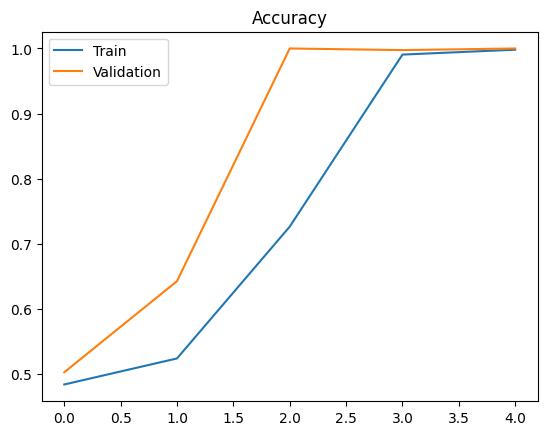

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
[[199   0]
 [  0 201]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       199
           1       1.00      1.00      1.00       201

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
# 🎯 Scenario: Medical Image Classification
# You’re training a convolutional neural network (CNN) to detect pneumonia from chest X-rays.
# - Training accuracy: 95%
# - Validation accuracy: 74%
# At first glance, the model seems powerful — it almost perfectly classifies the training set. But the sharp drop in validation accuracy signals overfitting: the network has memorized the training images (specific pixel patterns, noise, or even hospital-specific artifacts) instead of learning generalizable features of pneumonia.

# ⚙️ Levers to Address Overfitting
# - Data Augmentation: Rotate, flip, and adjust brightness of X-rays to simulate variability.
# - Regularization: Apply dropout in dense layers or L2 weight decay.
# - Transfer Learning: Use a pretrained backbone (e.g., ResNet) to leverage generalized features.
# - Cross-validation: Ensure robustness across different patient subsets.
# - Early Stopping: Halt training when validation loss stops improving.

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# Create Synthetic Dataset
# -----------------------------
IMG_SIZE = 64
NUM_SAMPLES = 2000

X = []
y = []

for i in range(NUM_SAMPLES):

    # base random noise image
    img = np.random.normal(0.5, 0.2, (IMG_SIZE, IMG_SIZE, 1))

    if i < NUM_SAMPLES//2:
        # NORMAL class
        label = 0
    else:
        # PNEUMONIA class → add bright patch
        label = 1
        x = np.random.randint(10,50)
        y_pos = np.random.randint(10,50)
        img[x:x+8, y_pos:y_pos+8] += 1

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

# normalize
X = np.clip(X,0,1)

# -----------------------------
# Train Validation Split
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Data Augmentation
# -----------------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# -----------------------------
# CNN Model
# -----------------------------
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(64,64,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early Stopping
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    validation_data=(X_val,y_val),
    epochs=5,
    callbacks=[early_stop]
)

# -----------------------------
# Plot Accuracy
# -----------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

# -----------------------------
# Predictions
# -----------------------------
pred = model.predict(X_val)
pred = (pred>0.5).astype(int)

print(confusion_matrix(y_val,pred))
print(classification_report(y_val,pred))